# 02 — Extração de Features Manuais

**Objetivo:** Extrair, para cada grão de café, um vetor de features manuais cobrindo:
- **Forma:** área, perímetro, excentricidade, solidez, extent, circularidade
- **Momentos de Hu:** 7 momentos invariantes (log-escala)
- **Cor:** média e desvio-padrão dos canais HSV dentro da máscara
- **Textura (GLCM):** contraste, homogeneidade, energia, correlação

Ao final, exportar `X.csv` (features) e `y.csv` (rótulos) para o notebook de classificação.

In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────
import os, json, warnings
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.notebook import tqdm
from skimage.feature import graycomatrix, graycoprops
from skimage.measure import label as sk_label, regionprops
from scipy import stats as sp_stats

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

OUTPUTS_DIR = Path('../outputs')
OUTPUTS_DIR.mkdir(exist_ok=True)

print('Imports carregados.')

Imports carregados.


In [2]:
# ── Carregar configurações do notebook 01 ────────────────────────────────────
with open(OUTPUTS_DIR / 'pipeline_config.json') as f:
    CONFIG = json.load(f)

CHOSEN_METHOD = CONFIG['chosen_method']
TARGET_SIZE   = tuple(CONFIG['target_size'])
LABEL_MAP     = {cls: tuple(v) for cls, v in CONFIG['label_map'].items()}
FINAL_CLASSES = {int(k): v for k, v in CONFIG['final_classes'].items()}

records_df = pd.read_csv(OUTPUTS_DIR / 'image_records.csv')
valid_df   = records_df[records_df['mask_ok']].copy().reset_index(drop=True)

print(f'Método de segmentação: {CHOSEN_METHOD}')
print(f'Imagens válidas: {len(valid_df)}')
print(f'Classes finais ({len(FINAL_CLASSES)}): {list(FINAL_CLASSES.values())}')

Método de segmentação: HSV
Imagens válidas: 1958
Classes finais (17): ['Broken', 'Cut', 'Dry Cherry', 'Fade', 'Floater', 'Full Black', 'Full Sour', 'Fungus Damange', 'Husk', 'Immature', 'Parchment', 'Partial Black', 'Partial Sour', 'Severe Insect Damange', 'Shell', 'Slight Insect Damage', 'Withered']


## 1. Funções de segmentação (reutilizadas do notebook 01)

In [3]:
def load_image(path, target_size=(256, 256)):
    img = cv2.imread(str(path))
    if img is None:
        return None
    return cv2.resize(img, target_size, interpolation=cv2.INTER_AREA)

def segment_hsv(bgr_img):
    hsv = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)
    _, mask_v = cv2.threshold(v, 30, 255, cv2.THRESH_BINARY)
    _, mask_s = cv2.threshold(s, 20, 255, cv2.THRESH_BINARY)
    mask = cv2.bitwise_or(mask_v, mask_s)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=3)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    if num_labels > 1:
        largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        mask = (labels == largest).astype(np.uint8) * 255
    return mask

def segment_canny(bgr_img):
    gray = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    otsu_thresh, _ = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    edges = cv2.Canny(blurred, otsu_thresh * 0.5, otsu_thresh)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11))
    closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel, iterations=3)
    contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    mask = np.zeros_like(gray)
    if contours:
        largest_cnt = max(contours, key=cv2.contourArea)
        cv2.drawContours(mask, [largest_cnt], -1, 255, thickness=cv2.FILLED)
    k2 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask = cv2.dilate(mask, k2, iterations=2)
    return mask

SEGMENT_FN = segment_hsv if CHOSEN_METHOD == 'HSV' else segment_canny
print(f'Função de segmentação ativa: {CHOSEN_METHOD}')

Função de segmentação ativa: HSV


## 2. Extratores de features

### 2.1 Features de Forma

In [4]:
def extract_shape_features(mask):
    """
    Extrai features de forma a partir da máscara binária.
    Retorna dict com: area, perimeter, eccentricity, solidity, extent, circularity.
    """
    labeled = sk_label(mask > 0)
    props_list = regionprops(labeled)
    if not props_list:
        return {k: 0.0 for k in
                ['shape_area', 'shape_perimeter', 'shape_eccentricity',
                 'shape_solidity', 'shape_extent', 'shape_circularity']}

    # Maior região
    props = max(props_list, key=lambda p: p.area)

    area      = float(props.area)
    perimeter = float(props.perimeter) if props.perimeter > 0 else 1.0
    circ      = (4 * np.pi * area) / (perimeter ** 2)

    return {
        'shape_area':          area / (mask.shape[0] * mask.shape[1]),  # normalizado
        'shape_perimeter':     perimeter / (2 * sum(mask.shape)),        # normalizado
        'shape_eccentricity':  float(props.eccentricity),
        'shape_solidity':      float(props.solidity),
        'shape_extent':        float(props.extent),
        'shape_circularity':   float(np.clip(circ, 0, 1))
    }

print('extract_shape_features definida.')

extract_shape_features definida.


### 2.2 Momentos de Hu

In [5]:
def extract_hu_moments(mask):
    """
    Calcula os 7 momentos de Hu invariantes a translação, rotação e escala.
    Aplica transformação logarítmica: sign(h) * log10(|h| + 1e-10).
    """
    moments = cv2.moments(mask)
    hu = cv2.HuMoments(moments).flatten()
    hu_log = -np.sign(hu) * np.log10(np.abs(hu) + 1e-10)
    return {f'hu_{i+1}': float(v) for i, v in enumerate(hu_log)}

print('extract_hu_moments definida.')

extract_hu_moments definida.


### 2.3 Features de Cor (HSV)

In [6]:
def extract_color_features(bgr_img, mask):
    """
    Extrai média e desvio-padrão dos canais HSV dentro da região do grão (máscara).
    Também inclui 8 bins do histograma de Matiz (H) normalizados.
    """
    hsv = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2HSV).astype(np.float32)
    channel_names = ['H', 'S', 'V']
    feats = {}

    for i, name in enumerate(channel_names):
        ch = hsv[:, :, i]
        pixels = ch[mask > 0]
        feats[f'color_{name}_mean'] = float(pixels.mean()) if len(pixels) else 0.0
        feats[f'color_{name}_std']  = float(pixels.std())  if len(pixels) else 0.0

    # Histograma de matiz com 8 bins (apenas dentro da máscara)
    h_channel = hsv[:, :, 0].astype(np.uint8)
    hist = cv2.calcHist([h_channel], [0], mask, [8], [0, 180])
    hist = hist.flatten()
    hist = hist / (hist.sum() + 1e-10)  # Normaliza
    for i, v in enumerate(hist):
        feats[f'color_H_hist_{i}'] = float(v)

    return feats

print('extract_color_features definida.')

extract_color_features definida.


### 2.4 Features de Textura (GLCM)

In [7]:
def extract_glcm_features(bgr_img, mask, distances=[1, 3], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4]):
    """
    Calcula GLCM sobre a região em escala de cinza delimitada pela máscara.
    Propriedades extraídas: contraste, homogeneidade, energia, correlação.
    Retorna média sobre todas as direções e distâncias.
    """
    gray = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2GRAY)

    # Aplica máscara: pixels fora do grão → 0
    masked_gray = gray.copy()
    masked_gray[mask == 0] = 0

    # Quantiza para 64 níveis (reduz custo computacional)
    img_q = (masked_gray // 4).astype(np.uint8)

    glcm = graycomatrix(img_q, distances=distances, angles=angles,
                        levels=64, symmetric=True, normed=True)

    props = ['contrast', 'homogeneity', 'energy', 'correlation']
    feats = {}
    for prop in props:
        val = graycoprops(glcm, prop).mean()
        feats[f'glcm_{prop}'] = float(val)

    return feats

print('extract_glcm_features definida.')

extract_glcm_features definida.


### 2.5 Extrator completo

In [8]:
def extract_all_features(bgr_img):
    """
    Pipeline completo de extração de features para uma imagem BGR.
    Retorna dict com todas as features ou None se segmentação falhar.
    """
    mask = SEGMENT_FN(bgr_img)
    if mask is None or np.count_nonzero(mask) < 100:
        return None

    feats = {}
    feats.update(extract_shape_features(mask))
    feats.update(extract_hu_moments(mask))
    feats.update(extract_color_features(bgr_img, mask))
    feats.update(extract_glcm_features(bgr_img, mask))
    return feats

# Teste rápido numa imagem
test_path = valid_df['path'].iloc[0]
test_img  = load_image(test_path, TARGET_SIZE)
test_feats = extract_all_features(test_img)
print(f'Número de features extraídas: {len(test_feats)}')
print('Nomes das features:')
for k in test_feats:
    print(f'  {k}: {test_feats[k]:.4f}')

Número de features extraídas: 31
Nomes das features:
  shape_area: 1.0000
  shape_perimeter: 0.9961
  shape_eccentricity: 0.0000
  shape_solidity: 1.0000
  shape_extent: 1.0000
  shape_circularity: 0.7916
  hu_1: 3.1847
  hu_2: 0.0000
  hu_3: 0.0000
  hu_4: 0.0000
  hu_5: 0.0000
  hu_6: 0.0000
  hu_7: 0.0000
  color_H_mean: 102.4575
  color_H_std: 59.2845
  color_S_mean: 19.4013
  color_S_std: 36.3587
  color_V_mean: 201.1480
  color_V_std: 23.8226
  color_H_hist_0: 0.2889
  color_H_hist_1: 0.0153
  color_H_hist_2: 0.0006
  color_H_hist_3: 0.0005
  color_H_hist_4: 0.0134
  color_H_hist_5: 0.1679
  color_H_hist_6: 0.3896
  color_H_hist_7: 0.1238
  glcm_contrast: 2.1720
  glcm_homogeneity: 0.8231
  glcm_energy: 0.4857
  glcm_correlation: 0.9813


## 3. Extração em lote (pipeline completo)

In [9]:
feature_list = []
label_list   = []
failed_paths = []

for _, row in tqdm(valid_df.iterrows(), total=len(valid_df), desc='Extraindo features'):
    bgr = load_image(row['path'], TARGET_SIZE)
    if bgr is None:
        failed_paths.append(row['path'])
        continue

    feats = extract_all_features(bgr)
    if feats is None:
        failed_paths.append(row['path'])
        continue

    feature_list.append(feats)
    label_list.append(row['label_index'])

print(f'\nFeatures extraídas com sucesso: {len(feature_list)}')
print(f'Imagens ignoradas (falha): {len(failed_paths)}')

Extraindo features:   0%|          | 0/1958 [00:00<?, ?it/s]


Features extraídas com sucesso: 1958
Imagens ignoradas (falha): 0


In [10]:
# ── Montar e exportar X.csv e y.csv ──────────────────────────────────────────
X = pd.DataFrame(feature_list)
y = pd.Series(label_list, name='label')

# Checar por NaN e substituir por mediana da coluna
n_nan = X.isna().sum().sum()
if n_nan > 0:
    print(f'Atenção: {n_nan} valores NaN detectados → substituídos pela mediana.')
    X = X.fillna(X.median())

X.to_csv(OUTPUTS_DIR / 'X.csv', index=False)
y.to_csv(OUTPUTS_DIR / 'y.csv', index=False)

print(f'X.csv salvo: shape {X.shape}')
print(f'y.csv salvo: {y.nunique()} classes, distribuição:')
print(y.value_counts().sort_index().rename(FINAL_CLASSES))

X.csv salvo: shape (1958, 31)
y.csv salvo: 17 classes, distribuição:
label
Broken                   124
Cut                      132
Dry Cherry               108
Fade                      70
Floater                   96
Full Black                82
Full Sour                150
Fungus Damange           150
Husk                     106
Immature                 156
Parchment                108
Partial Black            130
Partial Sour             100
Severe Insect Damange    114
Shell                    114
Slight Insect Damage     110
Withered                 108
Name: count, dtype: int64


## 4. Análise exploratória de features

### 4.1 Boxplots por classe (features mais discriminantes)

In [11]:
# Adiciona coluna de nome da classe ao DataFrame para visualização
Xplot = X.copy()
Xplot['class_name'] = y.map(FINAL_CLASSES)

# Seleciona as features mais discriminantes usando variância inter-classe (ANOVA F)
from sklearn.feature_selection import f_classif
f_vals, p_vals = f_classif(X, y)
feat_importance = pd.Series(f_vals, index=X.columns).sort_values(ascending=False)

top_features = feat_importance.head(12).index.tolist()
print('Top 12 features mais discriminantes (ANOVA F-score):')
for feat, score in feat_importance.head(12).items():
    print(f'  {feat:35s}  F={score:.2f}')

Top 12 features mais discriminantes (ANOVA F-score):
  color_V_std                          F=500.49
  glcm_contrast                        F=260.68
  color_V_mean                         F=163.91
  color_S_std                          F=148.97
  color_S_mean                         F=106.70
  color_H_hist_5                       F=101.36
  color_H_hist_2                       F=100.11
  color_H_hist_1                       F=97.43
  glcm_homogeneity                     F=90.83
  color_H_hist_0                       F=86.60
  glcm_energy                          F=78.83
  color_H_std                          F=77.76


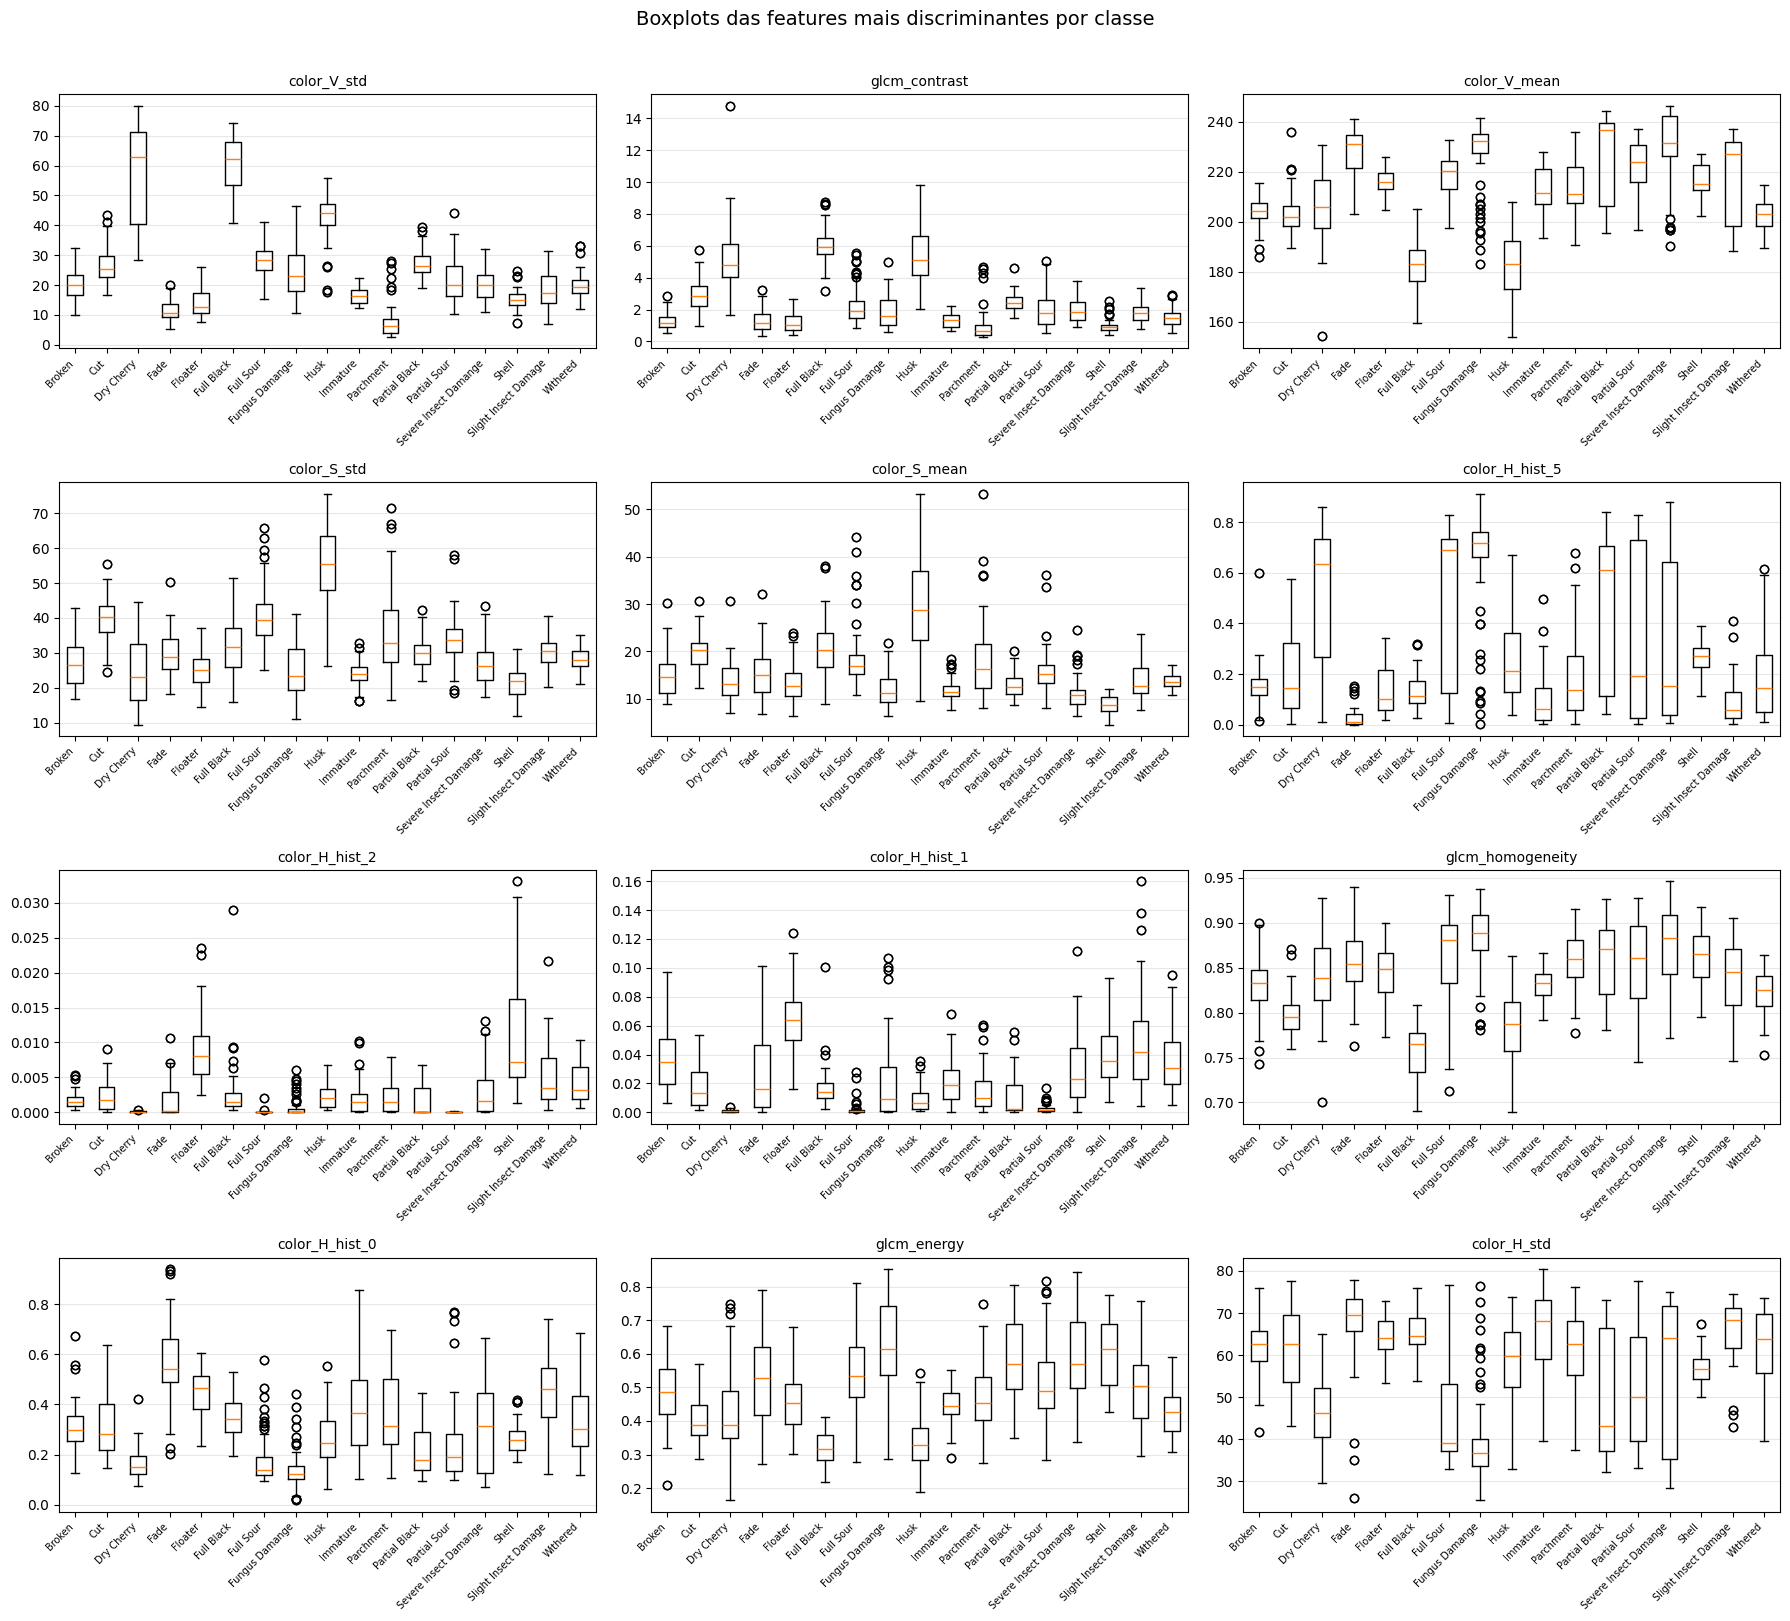

Figura salva em outputs/boxplots_features.png


In [12]:
# Boxplots para top 12 features
n_cols = 3
n_rows = len(top_features) // n_cols + int(len(top_features) % n_cols != 0)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flat

for ax, feat in zip(axes, top_features):
    data = [Xplot.loc[Xplot['class_name'] == cls, feat].values
            for cls in Xplot['class_name'].unique()]
    class_labels = Xplot['class_name'].unique()
    ax.boxplot(data, labels=class_labels, vert=True)
    ax.set_title(feat, fontsize=10)
    ax.set_xticklabels(class_labels, rotation=45, ha='right', fontsize=7)
    ax.grid(axis='y', alpha=0.3)

for ax in list(axes)[len(top_features):]:
    ax.set_visible(False)

plt.suptitle('Boxplots das features mais discriminantes por classe', fontsize=14, y=1.01)
plt.tight_layout()
fig.savefig(OUTPUTS_DIR / 'boxplots_features.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura salva em outputs/boxplots_features.png')

### 4.2 Tabela: médias e medianas por classe

In [13]:
stats_table = Xplot.groupby('class_name')[top_features[:6]].agg(['mean', 'median'])
stats_table.columns = ['_'.join(c) for c in stats_table.columns]
stats_table = stats_table.round(4)

print('Tabela: médias e medianas das principais features por classe')
display(stats_table)

Tabela: médias e medianas das principais features por classe


,color_V_std_mean,color_V_std_median,glcm_contrast_mean,glcm_contrast_median,color_V_mean_mean,color_V_mean_median,color_S_std_mean,color_S_std_median,color_S_mean_mean,color_S_mean_median,color_H_hist_5_mean,color_H_hist_5_median
class_name,,,,,,,,,,,,
Broken,19.9783,19.8533,1.2669,1.1494,204.3341,204.4452,27.3655,26.5853,14.9075,14.6048,0.1497,0.1495
Cut,26.3745,25.3668,2.8671,2.8440,202.9467,201.9243,39.7002,40.1890,19.8302,20.2755,0.1966,0.1450
Dry Cherry,58.0542,62.8058,5.1369,4.8266,206.4557,205.7549,24.8344,23.2008,13.7975,13.1378,0.5189,0.6344
Fade,11.7938,10.7410,1.3179,1.1686,228.4131,231.1448,29.8071,28.7674,15.5884,14.9481,0.0311,0.0097
Floater,13.8320,12.6024,1.1776,1.0278,216.1232,215.8314,25.4248,25.1134,13.5354,12.6130,0.1320,0.0999
Full Black,60.2007,62.1325,6.1094,5.9024,182.7911,182.9889,32.1341,31.6628,20.7938,20.2988,0.1337,0.1123
Full Sour,28.0663,28.4477,2.2944,1.9069,218.1001,220.0436,40.3329,39.3148,18.5154,17.0256,0.5329,0.6912
Fungus Damange,24.2819,22.8752,1.8913,1.6116,227.2015,232.1733,25.0881,23.4737,11.8393,11.1354,0.6542,0.7185
Husk,42.6031,44.1813,5.5280,5.1325,182.2556,183.0890,54.8652,55.4532,29.4157,28.7244,0.2519,0.2106


### 4.3 Matriz de correlação entre features

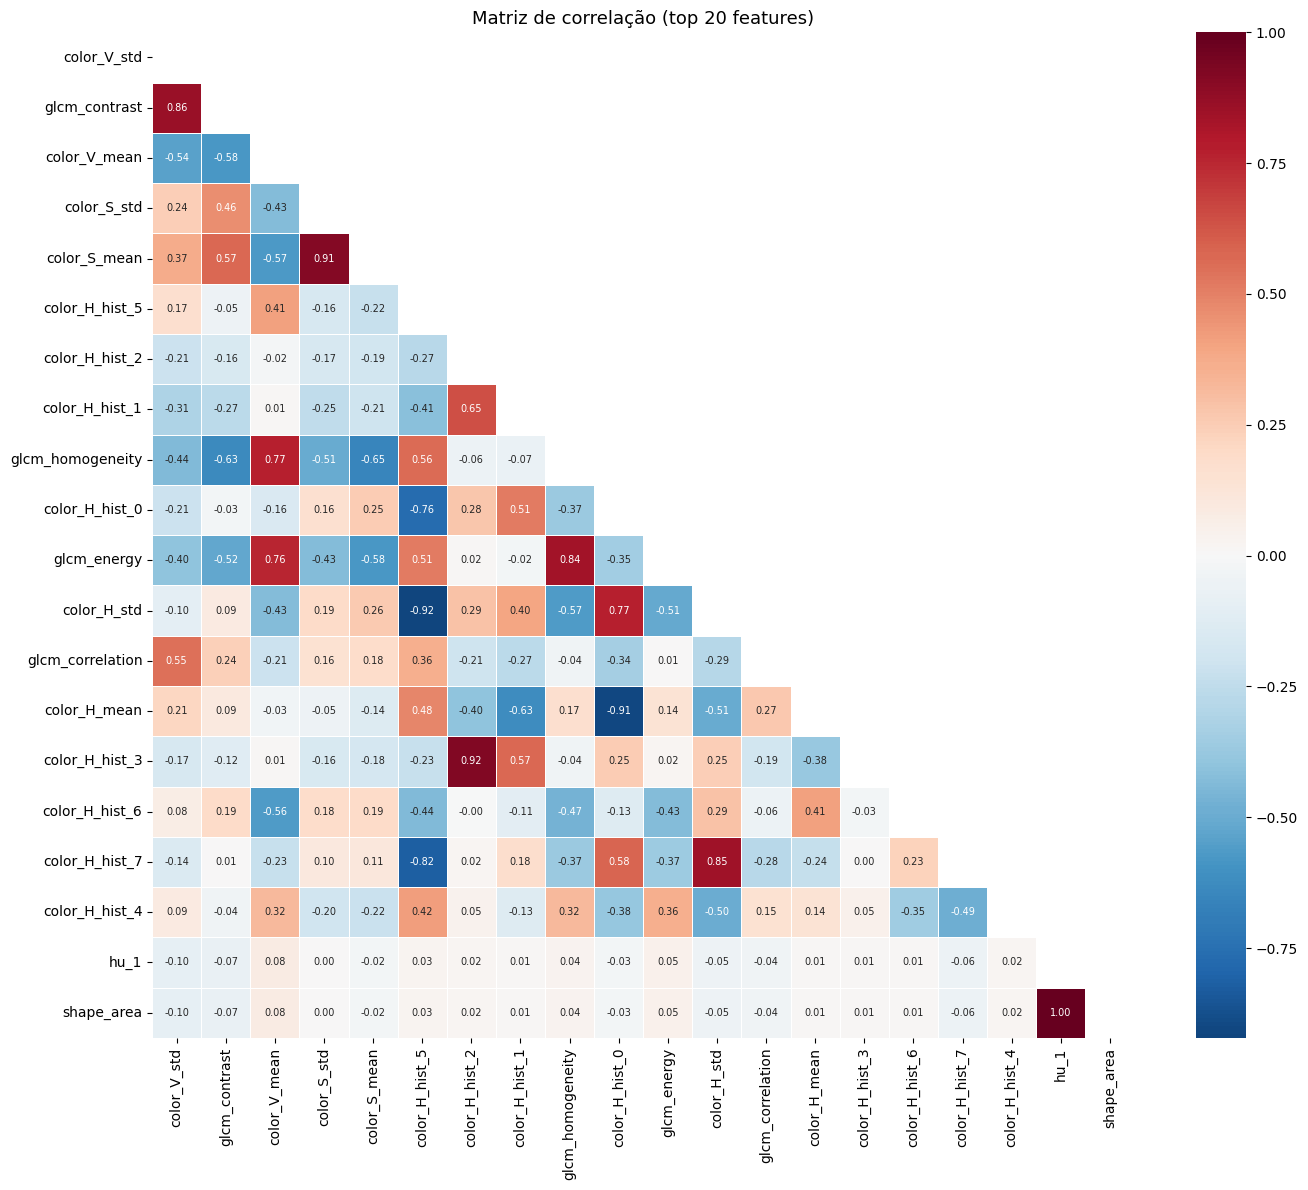

In [14]:
# Correlação de Pearson entre features (apenas as top 20 para clareza)
top20 = feat_importance.head(20).index.tolist()
corr_matrix = X[top20].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask_tri = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask_tri, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, annot_kws={'size': 7}, linewidths=0.5)
ax.set_title('Matriz de correlação (top 20 features)', fontsize=13)
plt.tight_layout()
fig.savefig(OUTPUTS_DIR / 'correlacao_features.png', dpi=150)
plt.show()

### 4.4 PCA — Visualização 2D das features

Variância explicada — PC1: 42.11%, PC2: 18.96%, Total: 61.07%


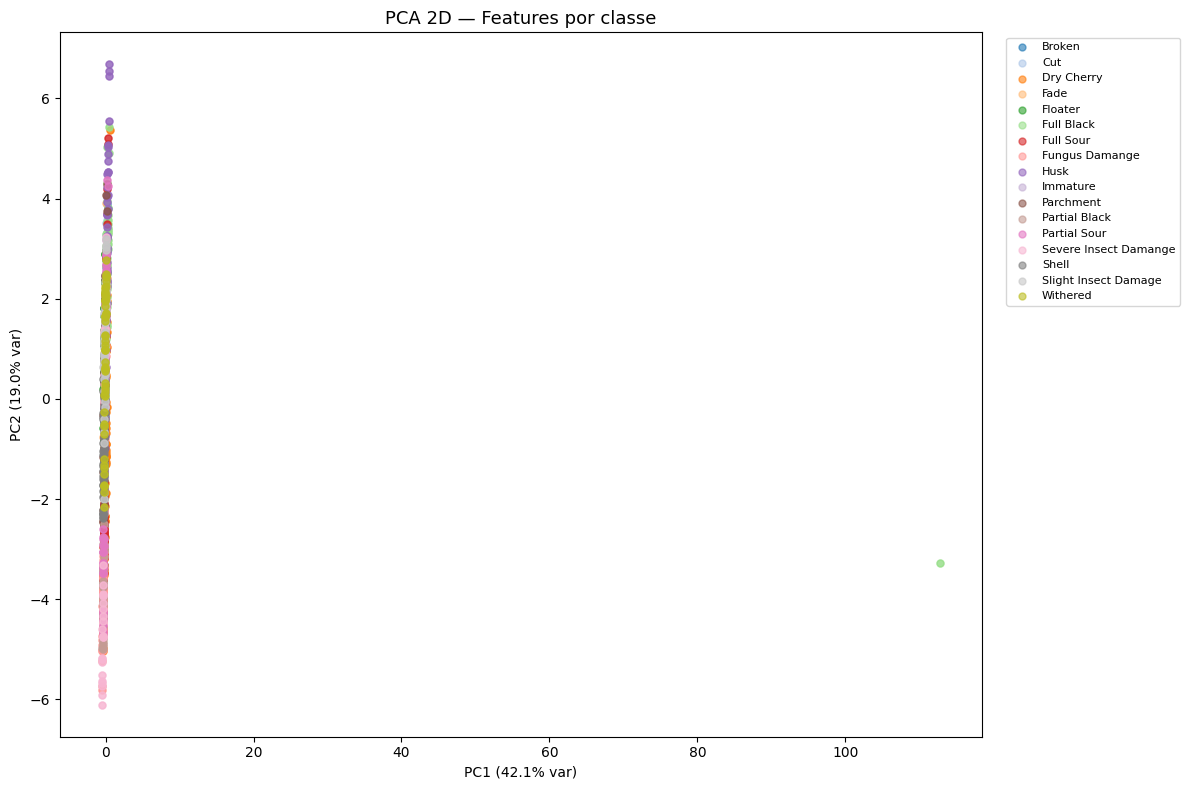

In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler_pca = StandardScaler()
X_scaled = scaler_pca.fit_transform(X)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

evr = pca.explained_variance_ratio_
print(f'Variância explicada — PC1: {evr[0]:.2%}, PC2: {evr[1]:.2%}, Total: {sum(evr):.2%}')

pca_df = pd.DataFrame({'PC1': X_pca[:, 0], 'PC2': X_pca[:, 1],
                        'class': y.map(FINAL_CLASSES)})

fig, ax = plt.subplots(figsize=(12, 8))
palette = sns.color_palette('tab20', n_colors=pca_df['class'].nunique())
for i, (cls, grp) in enumerate(pca_df.groupby('class')):
    ax.scatter(grp['PC1'], grp['PC2'], label=cls, alpha=0.6,
               s=25, color=palette[i % len(palette)])

ax.set_xlabel(f'PC1 ({evr[0]:.1%} var)')
ax.set_ylabel(f'PC2 ({evr[1]:.1%} var)')
ax.set_title('PCA 2D — Features por classe', fontsize=13)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8, ncol=1)
plt.tight_layout()
fig.savefig(OUTPUTS_DIR / 'pca_2d.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.5 SelectKBest — Ranking global de features

Top 20 features por F-score (ANOVA):


,feature,F_score,p_value
0,color_V_std,500.485121,0.000000e+00
1,glcm_contrast,260.675300,0.000000e+00
2,color_V_mean,163.911900,0.000000e+00
3,color_S_std,148.974732,0.000000e+00
4,color_S_mean,106.701205,8.776040e-252
5,color_H_hist_5,101.359886,7.084768e-242
6,color_H_hist_2,100.109184,1.598819e-239
7,color_H_hist_1,97.428633,1.959154e-234
8,glcm_homogeneity,90.828352,1.218590e-221
9,color_H_hist_0,86.596753,3.123401e-213


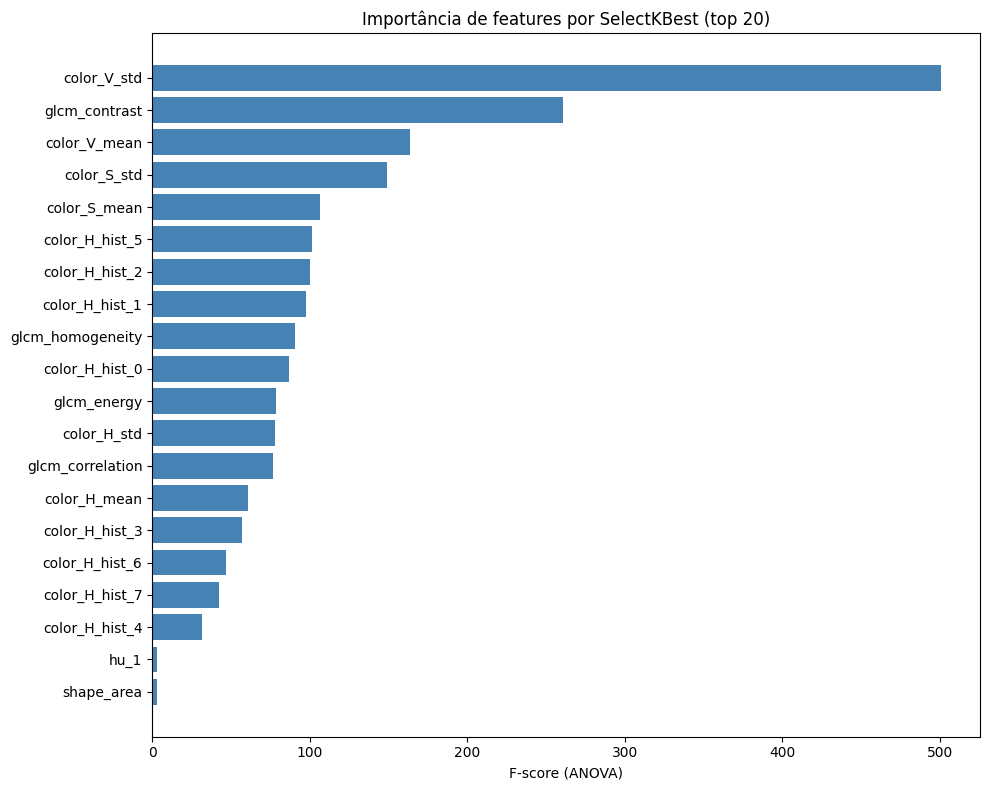

In [16]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(f_classif, k='all')
selector.fit(X, y)

ranking = pd.DataFrame({
    'feature': X.columns,
    'F_score': selector.scores_,
    'p_value': selector.pvalues_
}).sort_values('F_score', ascending=False).reset_index(drop=True)

print('Top 20 features por F-score (ANOVA):')
display(ranking.head(20))

# Gráfico de barras
fig, ax = plt.subplots(figsize=(10, 8))
top_rank = ranking.head(20)
ax.barh(top_rank['feature'][::-1], top_rank['F_score'][::-1], color='steelblue')
ax.set_xlabel('F-score (ANOVA)')
ax.set_title('Importância de features por SelectKBest (top 20)', fontsize=12)
plt.tight_layout()
fig.savefig(OUTPUTS_DIR / 'feature_importance_anova.png', dpi=150)
plt.show()

In [17]:
# ── Análise qualitativa das features ─────────────────────────────────────────
print('\n=== Análise qualitativa das features ===')
print()
groups = {
    'Forma':        [f for f in X.columns if f.startswith('shape_')],
    'Momentos Hu':  [f for f in X.columns if f.startswith('hu_')],
    'Cor (HSV)':    [f for f in X.columns if f.startswith('color_') and 'hist' not in f],
    'Hist. Matiz':  [f for f in X.columns if 'hist' in f],
    'Textura GLCM': [f for f in X.columns if f.startswith('glcm_')]
}

for group, feats in groups.items():
    group_scores = ranking.set_index('feature').loc[feats, 'F_score']
    print(f'{group:20s}: {len(feats)} features | F-score médio = {group_scores.mean():.2f} | top: {group_scores.idxmax()}')

print('\nConclusão: Features de COR (principalmente H_mean e S_mean) e TEXTURA (contraste, energia)')
print('tendem a ser as mais discriminantes para separar defeitos de café verde.')


=== Análise qualitativa das features ===

Forma               : 6 features | F-score médio = 2.91 | top: shape_area
Momentos Hu         : 7 features | F-score médio = 2.91 | top: hu_1
Cor (HSV)           : 6 features | F-score médio = 176.43 | top: color_V_std
Hist. Matiz         : 8 features | F-score médio = 70.46 | top: color_H_hist_5
Textura GLCM        : 4 features | F-score médio = 126.77 | top: glcm_contrast

Conclusão: Features de COR (principalmente H_mean e S_mean) e TEXTURA (contraste, energia)
tendem a ser as mais discriminantes para separar defeitos de café verde.


In [18]:
print(f'\n✅ Features extraídas com sucesso!')
print(f'   Amostras: {X.shape[0]} | Features: {X.shape[1]}')
print(f'   Arquivos salvos: outputs/X.csv, outputs/y.csv')
print(f'   Figuras salvas: outputs/boxplots_features.png, pca_2d.png, correlacao_features.png')


✅ Features extraídas com sucesso!
   Amostras: 1958 | Features: 31
   Arquivos salvos: outputs/X.csv, outputs/y.csv
   Figuras salvas: outputs/boxplots_features.png, pca_2d.png, correlacao_features.png
